In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:

csv_path = "./runs/detect/yolov11m_no_pretrain_300/results.csv"  # change if your file is elsewhere
df = pd.read_csv(csv_path)

In [5]:
numeric_cols = df.select_dtypes(include="number").columns
summary = df[numeric_cols].describe().T
print("\nSummary statistics for numeric columns:")
print(summary)



Summary statistics for numeric columns:
                      count          mean          std         min  \
epoch                  99.0     50.000000    28.722813    1.000000   
time                   99.0  14119.382747  8866.855460  616.372000   
train/box_loss         99.0      1.472195     0.145063    1.330480   
train/cls_loss         99.0      1.152907     0.415801    0.888320   
train/dfl_loss         99.0      1.504481     0.138315    1.371980   
metrics/precision(B)   99.0      0.924643     0.082777    0.469320   
metrics/recall(B)      99.0      0.876251     0.094258    0.427270   
metrics/mAP50(B)       99.0      0.923301     0.098062    0.395130   
metrics/mAP50-95(B)    99.0      0.524884     0.085471    0.126510   
val/box_loss           99.0      1.539782     0.152618    1.467630   
val/cls_loss           99.0      0.798555     0.385253    0.625250   
val/dfl_loss           99.0      1.437988     0.147447    1.357130   
lr/pg0                 99.0      0.008282     0.0

In [ ]:

def plot_lines(x, cols, title, xlabel="epoch"):
    plt.figure(figsize=(8, 5))

    for col in cols:
        if col in df.columns:
            y = df[col]

            # Plot the line
            plt.plot(x, y, label=col)

            # Get last point
            last_x = x.iloc[-1] if hasattr(x, "iloc") else x[-1]
            last_y = y.iloc[-1]

            # Draw a marker on the last point
            plt.scatter([last_x], [last_y])

            # Add a text label slightly offset from the point
            plt.annotate(
                f"{col}: {last_y:.4f}",
                xy=(last_x, last_y),
                xytext=(5, 5),  # offset in points
                textcoords="offset points",
                fontsize=8,
            )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Decide what to use for x-axis (epoch preferred)
if "epoch" in df.columns:
    x = df["epoch"]
    x_label = "epoch"
else:
    x = df.index
    x_label = "index"



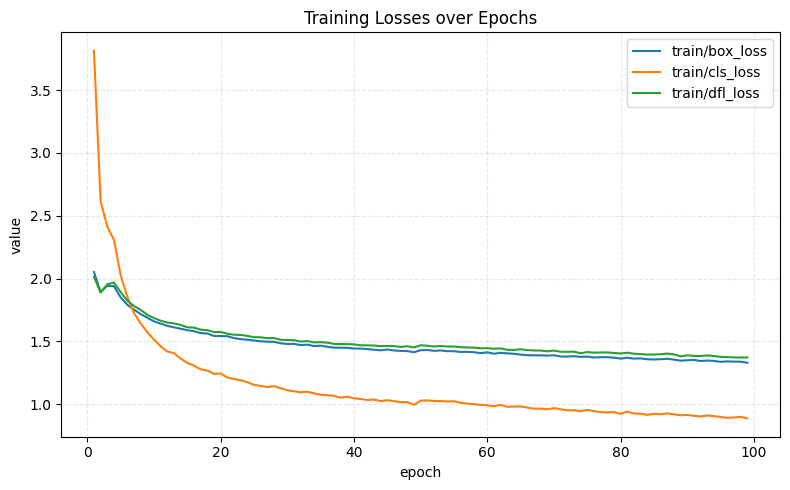

In [ ]:

train_loss_cols = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss",
]

plot_lines(x, train_loss_cols, "Training Losses over Epochs", xlabel=x_label)

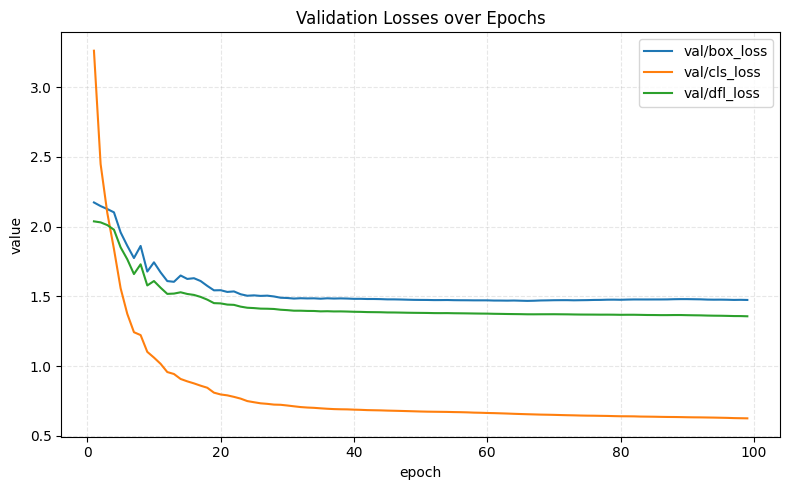

In [8]:

val_loss_cols = [
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss",
]

plot_lines(x, val_loss_cols, "Validation Losses over Epochs", xlabel=x_label)



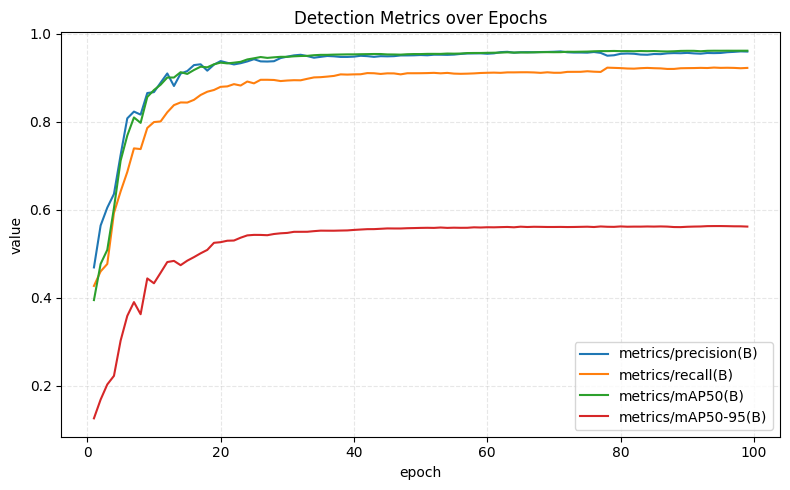

In [9]:

metric_cols = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

plot_lines(x, metric_cols, "Detection Metrics over Epochs", xlabel=x_label)



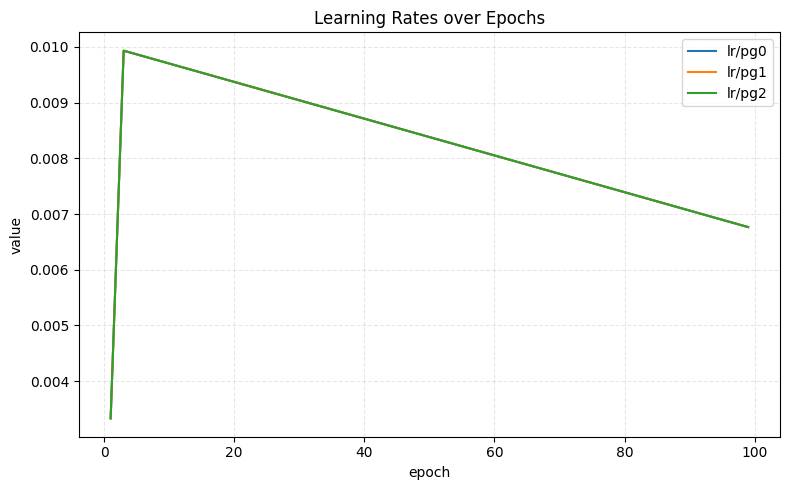

In [10]:

lr_cols = [
    "lr/pg0",
    "lr/pg1",
    "lr/pg2",
]

plot_lines(x, lr_cols, "Learning Rates over Epochs", xlabel=x_label)